你可以從 [Bookshop.org](https://bookshop.org/a/98697/9781098155438) 和 [Amazon](https://www.amazon.com/_/dp/1098155432?smid=ATVPDKIKX0DER&_encoding=UTF8&tag=oreilly20-20&_encoding=UTF8&tag=greenteapre01-20&linkCode=ur2&linkId=e2a529f94920295d27ec8a06e757dc7c&camp=1789&creative=9325) 訂購 *Think Python 3e* 的紙本和電子書版本。

In [1]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://github.com/AllenDowney/ThinkPython/raw/v3/thinkpython.py');
download('https://github.com/AllenDowney/ThinkPython/raw/v3/diagram.py');

import thinkpython

# 類別和函數

到此為止，你知道如何使用函數來組織程式碼，以及如何使用內建類型來組織資料。
下一步是**物件導向程式設計**，它使用程式設計師定義的類型來組織程式碼和資料。

物件導向程式設計是一個很大的主題，所以我們將逐步進行。
在本章中，我們將從不夠慣用的程式碼開始——也就是說，它不是有經驗的程式設計師會寫的那種程式碼——但它是一個很好的起點。
在接下來的兩章中，我們將使用額外的功能來寫出更慣用的程式碼。

## 程式設計師定義的類型

我們已經使用了許多 Python 的內建類型——現在我們將定義一個新類型。
作為第一個範例，我們將創建一個名為 `Time` 的類型來表示一天中的時間。
程式設計師定義的類型也稱為**類別**。
類別定義看起來像這樣：

In [2]:
class Time:
    """Represents a time of day."""

標頭表示新類別名為 `Time`。
主體是一個文件字串，解釋類別的用途。
定義類別會創建一個**類別物件**。

類別物件就像創建物件的工廠。
要創建一個 `Time` 物件，你可以呼叫 `Time`，就像它是一個函數一樣。

In [3]:
lunch = Time()

結果是一個新物件，其類型是 `__main__.Time`，其中 `__main__` 是定義 `Time` 的模組名稱。

In [4]:
type(lunch)

__main__.Time

當你印出一個物件時，Python 會告訴你它是什麼類型以及它儲存在記憶體中的位置（前綴 `0x` 表示後面的數字是十六進位）。

In [5]:
print(lunch)

創建新物件稱為**實例化**，該物件是類別的**實例**。

## 屬性

物件可以包含變數，這些變數稱為**屬性**，讀音是第一個音節重音，像「AT-trib-ute」，而不是第二個音節重音，像「a-TRIB-ute」。
我們可以使用點記號法來創建屬性。

In [6]:
lunch.hour = 11
lunch.minute = 59
lunch.second = 1

此範例創建了名為 `hour`、`minute` 和 `second` 的屬性，分別包含時間 `11:59:01` 的小時、分鐘和秒，就我而言，這是午餐時間。

以下圖表顯示了這些賦值後 `lunch` 及其屬性的狀態。

In [7]:
from diagram import make_frame, make_binding

d1 = dict(hour=11, minute=59, second=1)
frame = make_frame(d1, name='Time', dy=-0.3, offsetx=0.48)
binding = make_binding('lunch', frame)

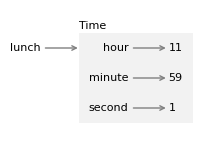

In [8]:
from diagram import diagram, adjust

width, height, x, y = [1.77, 1.24, 0.25, 0.86]
ax = diagram(width, height)
bbox = binding.draw(ax, x, y)
#adjust(x, y, bbox)

變數 `lunch` 指向一個 `Time` 物件，該物件包含三個屬性。
每個屬性指向一個整數。
像這樣顯示物件及其屬性的狀態圖稱為**物件圖**。

你可以使用點運算子讀取屬性的值。

In [9]:
lunch.hour

11

你可以將屬性用作任何表達式的一部分。

In [10]:
total_minutes = lunch.hour * 60 + lunch.minute
total_minutes

719

你可以在 f-字串的表達式中使用點運算子。

In [11]:
f'{lunch.hour}:{lunch.minute}:{lunch.second}'

'11:59:1'

但注意前面的範例不是標準格式。
要修正它，我們必須在 `minute` 和 `second` 屬性前面印出前導零。
我們可以通過擴展大括號中的表達式來使用**格式規範符**。
在以下範例中，格式規範符表示 `minute` 和 `second` 應該至少以兩位數顯示，如果需要的話加上前導零。

In [12]:
f'{lunch.hour}:{lunch.minute:02d}:{lunch.second:02d}'

'11:59:01'

我們將使用此 f-字串來寫一個顯示 `Time` 物件值的函數。
你可以像平常一樣將物件作為參數傳遞。
例如，以下函數接受 `Time` 物件作為參數。

In [13]:
def print_time(time):
    s = f'{time.hour:02d}:{time.minute:02d}:{time.second:02d}'
    print(s)

當我們呼叫它時，我們可以將 `lunch` 作為參數傳遞。

In [14]:
print_time(lunch)

11:59:01


## 物件作為返回值

函數可以返回物件。例如，`make_time` 接受名為 `hour`、`minute` 和 `second` 的參數，將它們儲存為 `Time` 物件中的屬性，並返回新物件。

In [15]:
def make_time(hour, minute, second):
    time = Time()
    time.hour = hour
    time.minute = minute
    time.second = second
    return time

參數與屬性同名可能令人驚訝，但這是寫這樣函數的常見方式。
以下是我們如何使用 `make_time` 來創建 `Time` 物件。

In [16]:
time = make_time(11, 59, 1)
print_time(time)

11:59:01


## 物件是可變的

假設你要去看電影，如《蒙提·派森與聖杯》，它從 `9:20 PM` 開始並播放 `92` 分鐘，即一小時 `32` 分鐘。
電影什麼時候結束？

首先，我們將創建一個代表開始時間的 `Time` 物件。

In [17]:
start = make_time(9, 20, 0)
print_time(start)

09:20:00


要找到結束時間，我們可以修改 `Time` 物件的屬性，加上電影的播放時間。

In [18]:
start.hour += 1
start.minute += 32
print_time(start)

10:52:00


電影將在 10:52 PM 結束。

讓我們將此計算封裝在函數中，並將其一般化以接受電影播放時間的三個參數：`hours`、`minutes` 和 `seconds`。

In [19]:
def increment_time(time, hours, minutes, seconds):
    time.hour += hours
    time.minute += minutes
    time.second += seconds

以下是展示效果的範例。

In [20]:
start = make_time(9, 20, 0)
increment_time(start, 1, 32, 0)
print_time(start)

10:52:00


以下堆疊圖顯示了 `increment_time` 修改物件之前程式的狀態。

In [21]:
from diagram import Frame, Binding, Value, Stack

d1 = dict(hour=9, minute=20, second=0)
obj1 = make_frame(d1, name='Time', dy=-0.25, offsetx=0.78)

binding1 = make_binding('start', frame, draw_value=False, dx=0.7)
frame1 = Frame([binding1], name='__main__', loc='left', offsetx=-0.2)

binding2 = Binding(Value('time'), draw_value=False, dx=0.7, dy=0.35)
binding3 = make_binding('hours', 1)
binding4 = make_binding('minutes',32)
binding5 = make_binding('seconds', 0)
frame2 = Frame([binding2, binding3, binding4, binding5], name='increment_time', 
               loc='left', dy=-0.25, offsetx=0.08)

stack = Stack([frame1, frame2], dx=-0.3, dy=-0.5)

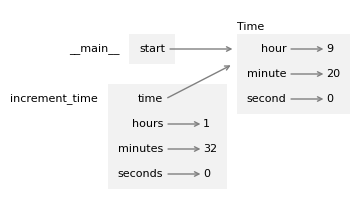

In [22]:
from diagram import Bbox

width, height, x, y = [3.4, 1.89, 1.75, 1.5]
ax = diagram(width, height)
bbox1 = stack.draw(ax, x, y)
bbox2 = obj1.draw(ax, x+0.23, y)
bbox = Bbox.union([bbox1, bbox2])
# adjust(x, y, bbox)

在函數內部，`time` 是 `start` 的別名，所以當 `time` 被修改時，`start` 也會改變。

此函數有效，但運行後，我們留下一個名為 `start` 的變數，它指向一個代表*結束*時間的物件，我們不再有代表開始時間的物件。
最好是讓 `start` 保持不變，並製作一個新物件來代表結束時間。
我們可以通過複製 `start` 並修改副本來做到這一點。

## 複製

`copy` 模組提供了一個名為 `copy` 的函數，可以複製任何物件。
我們可以像這樣匯入它。

In [23]:
from copy import copy

要看它如何運作，讓我們從一個代表電影開始時間的新 `Time` 物件開始。

In [24]:
start = make_time(9, 20, 0)

並製作一個副本。

In [25]:
end = copy(start)

現在 `start` 和 `end` 包含相同的資料。

In [26]:
print_time(start)
print_time(end)

09:20:00
09:20:00


但 `is` 運算子確認它們不是同一個物件。

In [27]:
start is end

False

讓我們看看 `==` 運算子做什麼。

In [28]:
start == end

False

你可能期望 `==` 會產生 `True`，因為物件包含相同的資料。
但對於程式設計師定義的類別，`==` 運算子的預設行為與 `is` 運算子相同——它檢查身分，而不是等價性。

## 純函數

我們可以使用 `copy` 來寫不修改其參數的純函數。
例如，以下是一個接受 `Time` 物件和以小時、分鐘和秒為單位的持續時間的函數。
它製作原始物件的副本，使用 `increment_time` 來修改副本，並返回它。

In [29]:
def add_time(time, hours, minutes, seconds):
    total = copy(time)
    increment_time(total, hours, minutes, seconds)
    return total

以下是我們如何使用它。

In [30]:
end = add_time(start, 1, 32, 0)
print_time(end)

10:52:00


返回值是代表電影結束時間的新物件。
我們可以確認 `start` 沒有改變。

In [31]:
print_time(start)

09:20:00


`add_time` 是一個**純函數**，因為它不修改任何傳遞給它作為參數的物件，並且它的唯一效果是返回一個值。

任何可以用非純函數完成的事情也可以用純函數完成。
事實上，有些程式語言只允許純函數。
使用純函數的程式可能不容易出錯，但非純函數有時更方便，也可能更高效。

一般來說，我建議你在合理的時候寫純函數，只有在有令人信服的優勢時才使用非純函數。
這種方法可能被稱為**函數式程式設計風格**。

## 原型和修補

在前面的範例中，`increment_time` 和 `add_time` 似乎運作正常，但如果我們嘗試另一個範例，我們會看到它們不太正確。

假設你到達戲院，發現電影從 `9:40` 開始，而不是 `9:20`。
以下是我們計算更新結束時間時發生的情況。

In [32]:
start = make_time(9, 40, 0)
end = add_time(start, 1, 32, 0)
print_time(end)

10:72:00


結果不是有效的時間。
問題是 `increment_time` 不處理秒數或分鐘數加起來超過 `60` 的情況。

以下是改進的版本，它檢查 `second` 是否超過或等於 `60`——如果是，它會增加 `minute`——然後檢查 `minute` 是否超過或等於 `60`——如果是，它會增加 `hour`。

In [33]:
def increment_time(time, hours, minutes, seconds):
    time.hour += hours
    time.minute += minutes
    time.second += seconds

    if time.second >= 60:
        time.second -= 60
        time.minute += 1

    if time.minute >= 60:
        time.minute -= 60
        time.hour += 1

修復 `increment_time` 也修復了 `add_time`，因為它使用它。
所以現在前面的範例正確運作。

In [34]:
end = add_time(start, 1, 32, 0)
print_time(end)

11:12:00


但此函數仍然不正確，因為參數可能大於 `60`。
例如，假設我們得到的運行時間是 `92` 分鐘，而不是 `1` 小時 `32` 分鐘。
我們可能會像這樣呼叫 `add_time`。

In [35]:
end = add_time(start, 0, 92, 0)
print_time(end)

10:72:00


結果不是有效的時間。
所以讓我們嘗試不同的方法，使用 `divmod` 函數。
我們將製作 `start` 的副本並通過增加 `minute` 屬性來修改它。

In [36]:
end = copy(start)
end.minute = start.minute + 92
end.minute

132

現在 `minute` 是 `132`，即 `2` 小時 `12` 分鐘。
我們可以使用 `divmod` 除以 `60` 並返回整小時數和剩餘的分鐘數。

In [37]:
carry, end.minute = divmod(end.minute, 60)
carry, end.minute

(2, 12)

現在 `minute` 正確，我們可以將小時加到 `hour`。

In [38]:
end.hour += carry
print_time(end)

11:12:00


結果是有效的時間。
我們可以對 `hour` 和 `second` 做同樣的事情，並將整個過程封裝在函數中。

In [39]:
def increment_time(time, hours, minutes, seconds):
    time.hour += hours
    time.minute += minutes
    time.second += seconds
    
    carry, time.second = divmod(time.second, 60)
    carry, time.minute = divmod(time.minute + carry, 60)
    carry, time.hour = divmod(time.hour + carry, 60)

有了這個版本的 `increment_time`，`add_time` 能正確運作，即使參數超過 `60`。

In [40]:
end = add_time(start, 0, 90, 120)
print_time(end)

11:12:00


這一節展示了我稱為**原型和修補**的程式開發計畫。
我們從一個對第一個範例正確運作的簡單原型開始。
然後我們用更困難的範例來測試它——當我們發現錯誤時，我們修改程式來修復它，就像在有破洞的輪胎上打補丁一樣。

這種方法可能有效，特別是如果你對問題還沒有深入理解。
但漸進式修正可能會產生不必要複雜的程式碼——因為它處理許多特殊情況——而且不可靠——因為很難知道你是否
找到了所有錯誤。

## 設計優先開發

另一種計畫是**設計優先開發**，它在原型製作之前涉及更多規劃。在設計優先過程中，有時對問題的高階洞察使程式設計變得更容易。

在這種情況下，洞察是我們可以將 `Time` 物件視為60進位的三位數字——也稱為六十進位。
`second` 屬性是「個位欄」，`minute` 屬性是「六十位欄」，
`hour` 屬性是「三千六百位欄」。
當我們寫 `increment_time` 時，我們實際上是在進行60進位加法，這就是為什麼我們必須從一欄進位到下一欄。

這個觀察建議了整個問題的另一種方法——我們可以將 `Time` 物件轉換為整數，並利用 Python 知道如何進行整數運算的事實。

以下是一個從 `Time` 轉換為整數的函數。

In [41]:
def time_to_int(time):
    minutes = time.hour * 60 + time.minute
    seconds = minutes * 60 + time.second
    return seconds

結果是從一天開始的秒數。
例如，`01:01:01` 是從一天開始的 `1` 小時、`1` 分鐘和 `1` 秒，即 `3600` 秒、`60` 秒和 `1` 秒的總和。

In [42]:
time = make_time(1, 1, 1)
print_time(time)
time_to_int(time)

01:01:01


3661

以下是一個朝相反方向的函數——將整數轉換為 `Time` 物件——使用 `divmod` 函數。

In [43]:
def int_to_time(seconds):
    minute, second = divmod(seconds, 60)
    hour, minute = divmod(minute, 60)
    return make_time(hour, minute, second)

我們可以通過將前面的範例轉換回 `Time` 來測試它。

In [44]:
time = int_to_time(3661)
print_time(time)

01:01:01


使用這些函數，我們可以寫一個更簡潔的 `add_time` 版本。

In [45]:
def add_time(time, hours, minutes, seconds):
    duration = make_time(hours, minutes, seconds)
    seconds = time_to_int(time) + time_to_int(duration)
    return int_to_time(seconds)

第一行將參數轉換為名為 `duration` 的 `Time` 物件。
第二行將 `time` 和 `duration` 轉換為秒並相加。
第三行將總和轉換為 `Time` 物件並返回它。

以下是它的運作方式。

In [46]:
start = make_time(9, 40, 0)
end = add_time(start, 1, 32, 0)
print_time(end)

11:12:00


在某些方面，從60進位轉換為10進位再轉換回來比
僅僅處理時間值更困難。進位轉換更抽象；我們
處理時間值的直覺更好。

但如果我們有將時間視為60進位數字的洞察——並投入精力編寫轉換函數 `time_to_int` 和 `int_to_time`——我們得到一個更短、更容易閱讀和除錯，並且更可靠的程式。

稍後添加功能也更容易。例如，想像減去兩個 `Time` 物件來找到它們之間的持續時間。
樸素的方法是實現有借位的減法。
使用轉換函數更容易，也更可能正確。

諷刺的是，有時使問題變得更困難——或更一般——使它變得更容易，因為有更少的特殊情況和更少的出錯機會。

## 除錯

Python 提供了幾個內建函數，對於測試和除錯處理物件的程式很有用。
例如，如果你不確定物件是什麼類型，你可以詢問。

In [47]:
type(start)

__main__.Time

你也可以使用 `isinstance` 來檢查物件是否為特定類別的實例。

In [48]:
isinstance(end, Time)

True

如果你不確定物件是否有特定屬性，你
可以使用內建函數 `hasattr`。

In [49]:
hasattr(start, 'hour')

True

要在字典中取得所有屬性及其值，你可以使用 `vars`。

In [50]:
vars(start)

{'hour': 9, 'minute': 40, 'second': 0}

我們在第11章中見過的 `structshape` 模組也能與程式設計師定義的類型一起運作。

In [51]:
download('https://raw.githubusercontent.com/AllenDowney/ThinkPython/v3/structshape.py');

In [52]:
from structshape import structshape

t = start, end
structshape(t)

'tuple of 2 Time'

## 詞彙表

**物件導向程式設計：**
使用物件來組織程式碼和資料的程式設計風格。

**類別：**
程式設計師定義的類型。類別定義創建新的類別物件。

**類別物件：**
代表類別的物件——它是類別定義的結果。

**實例化：**
創建屬於類別的物件的過程。

**實例：**
屬於類別的物件。

**屬性：**
與物件關聯的變數，也稱為實例變數。

**物件圖：**
物件、其屬性及其值的圖形表示。

**格式規範符：**
在 f-字串中，格式規範符決定值如何轉換為字串。

**純函數：**
不修改其參數或除了返回值之外沒有任何效果的函數。

**函數式程式設計風格：**
一種儘可能使用純函數的程式設計方式。

**原型和修補：**
一種程式開發方式，從粗略的草稿開始，逐步添加功能和修復錯誤。

**設計優先開發：**
一種比原型和修補更仔細規劃的程式開發方式。

## 練習

In [53]:
# This cell tells Jupyter to provide detailed debugging information
# when a runtime error occurs. Run it before working on the exercises.

%xmode Verbose

Exception reporting mode: Verbose


### 詢問虛擬助理

本章有很多新詞彙。
與虛擬助理對話可以幫助鞏固你的理解。
考慮詢問：

* 「類別和類型有什麼區別？」

* 「物件和實例有什麼區別？」

* 「變數和屬性有什麼區別？」

* 「純函數與非純函數相比有什麼優缺點？」

因為我們剛開始學習物件導向程式設計，本章中的程式碼並不慣用——它不是有經驗的程式設計師會寫的那種程式碼。
如果你請虛擬助理幫助你做練習，你可能會看到我們還沒有涵蓋的功能。
特別是，你可能會看到一個名為 `__init__` 的方法被用來初始化實例的屬性。

如果這些功能對你有意義，請繼續使用它們。
但如果沒有，請耐心等待——我們很快就會到達那裡。
同時，看看你是否能僅使用我們到目前為止涵蓋的功能來解決以下練習。

另外，在本章中我們看到了一個格式規範符的範例。要獲得更多資訊，請詢問「Python f-字串中可以使用什麼格式規範符？」

### 練習

寫一個名為 `subtract_time` 的函數，它接受兩個 `Time` 物件並返回它們之間的間隔秒數——假設它們是同一天中的兩個時間。

以下是函數的大綱，讓你開始。

In [54]:
def subtract_time(t1, t2):
    """Compute the difference between two times in seconds.
    
    >>> subtract_time(make_time(3, 2, 1), make_time(3, 2, 0))
    1
    >>> subtract_time(make_time(3, 2, 1), make_time(3, 0, 0))
    121
    >>> subtract_time(make_time(11, 12, 0), make_time(9, 40, 0))
    5520
    """
    return None

In [55]:
# Solution

def subtract_time(t1, t2):
    """Compute the difference between two times in seconds.
    
    >>> subtract_time(make_time(3, 2, 1), make_time(3, 2, 0))
    1
    >>> subtract_time(make_time(3, 2, 1), make_time(3, 0, 0))
    121
    >>> subtract_time(make_time(11, 12, 0), make_time(9, 40, 0))
    5520
    """
    return time_to_int(t1) - time_to_int(t2)

你可以使用 `doctest` 來測試你的函數。

In [56]:
from doctest import run_docstring_examples

def run_doctests(func):
    run_docstring_examples(func, globals(), name=func.__name__)

run_doctests(subtract_time)

### 練習

寫一個名為 `is_after` 的函數，它接受兩個 `Time` 物件，如果第一個時間在一天中比第二個時間晚，則返回 `True`，否則返回 `False`。

以下是函數的大綱，讓你開始。

In [57]:
def is_after(t1, t2):
    """Checks whether `t1` is after `t2`.
    
    >>> is_after(make_time(3, 2, 1), make_time(3, 2, 0))
    True
    >>> is_after(make_time(3, 2, 1), make_time(3, 2, 1))
    False
    >>> is_after(make_time(11, 12, 0), make_time(9, 40, 0))
    True
    """
    return None

In [58]:
# Solution

def is_after(t1, t2):
    """Checks whether `t1` is after `t2`.
    
    >>> is_after(make_time(3, 2, 1), make_time(3, 2, 0))
    True
    >>> is_after(make_time(3, 2, 1), make_time(3, 2, 1))
    False
    >>> is_after(make_time(11, 12, 0), make_time(9, 40, 0))
    True
    """
    return time_to_int(t1) > time_to_int(t2)

你可以使用 `doctest` 來測試你的函數。

In [59]:
run_doctests(is_after)

### 練習

以下是代表日期的 `Date` 類別定義——即年、月和日。

In [60]:
class Date:
    """Represents a year, month, and day"""

1. 寫一個名為 `make_date` 的函數，它接受 `year`、`month` 和 `day` 作為參數，製作一個 `Date` 物件，將參數指派給屬性，並返回結果新物件。創建一個代表 1933 年 6 月 22 日的物件。

2. 寫一個名為 `print_date` 的函數，它接受 `Date` 物件，使用 f-字串來格式化屬性，並印出結果。如果你用你創建的 `Date` 測試它，結果應該是 `1933-06-22`。

3. 寫一個名為 `is_after` 的函數，它接受兩個 `Date` 物件作為參數，如果第一個在第二個之後則返回 `True`。創建一個代表 1933 年 9 月 17 日的第二個物件，並檢查它是否在第一個物件之後。

提示：你可能會發現寫一個名為 `date_to_tuple` 的函數很有用，它接受 `Date` 物件並返回一個包含其屬性按年、月、日順序的元組。

你可以使用這個函數大綱來開始。

In [61]:
def make_date(year, month, day):
    return None

In [62]:
# Solution

def make_date(year, month, day):
    date = Date()
    date.year = year
    date.month = month
    date.day = day
    return date

你可以使用這些範例來測試 `make_date`。

In [63]:
birthday1 = make_date(1933, 6, 22)

In [64]:
birthday2 = make_date(1933, 9, 17)

你可以使用這個函數大綱來開始。

In [65]:
def print_date(date):
    print('')

In [66]:
# Solution

def print_date(date):
    s = f'{date.year}-{date.month:02d}-{date.day:02d}'
    print(s)

你可以使用這個範例來測試 `print_date`。

In [67]:
print_date(birthday1)

1933-06-22


你可以使用這個函數大綱來開始。

In [68]:
def is_after(date1, date2):
    return None

In [69]:
# Solution

def date_to_tuple(date):
    return date.year, date.month, date.day

In [70]:
# Solution

def is_after(date1, date2):
    t1 = date_to_tuple(date1)
    t2 = date_to_tuple(date2)
    return t1 > t2

你可以使用這些範例來測試 `is_after`。

In [71]:
is_after(birthday1, birthday2)  # should be False

False

In [72]:
is_after(birthday2, birthday1)  # should be True

True

[Think Python: 3rd Edition](https://allendowney.github.io/ThinkPython/index.html)

Copyright 2024 [Allen B. Downey](https://allendowney.com)

Code license: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)